# OCR with MATA

Demonstrates five OCR backends and common result workflows.
`OCRResult` auto-renders as a rich HTML table in Jupyter.

| Backend | Model string | Strengths |
|---------|-------------|-----------|
| EasyOCR | `"easyocr"` | 80+ languages, polygon bboxes |
| PaddleOCR | `"paddleocr"` | Strong on CJK scripts (**Python ≤ 3.12 only**) |
| Tesseract | `"tesseract"` | Classic engine, fast |
| TrOCR | `"microsoft/trocr-base-printed"` | Transformer, great for single-line crops |
| GLM-OCR | `"zai-org/GLM-OCR"` | State-of-the-art document OCR (v1.9.4+) |

**Prerequisites** — install the backend(s) you want to test:
```bash
pip install easyocr
pip install paddlepaddle paddleocr   # ⚠️ requires Python ≤ 3.12 — not available on Python 3.13+
pip install pytesseract              # also needs Tesseract binary on PATH
pip install transformers torch       # for TrOCR / GLM-OCR
```


In [ ]:
# Uncomment to install your preferred backend:
# !pip install easyocr
# !pip install paddlepaddle paddleocr
# !pip install pytesseract
# !pip install transformers torch   # TrOCR / GLM-OCR

In [1]:
from pathlib import Path
import mata

print(f"MATA version: {mata.__version__}")

# Image paths (bundled with the repo)
IMAGES_DIR     = Path("../../examples/images/ocr")
STOCKS_IMAGE   = str(IMAGES_DIR / "stocks.png")
RECEIPT_IMAGE  = str(IMAGES_DIR / "receipt.png")
LINE_IMAGE     = str(IMAGES_DIR / "ocr_test_mata.png")
DOCUMENT_IMAGE = str(IMAGES_DIR / "ocr_document.png")

for label, p in [("stocks", STOCKS_IMAGE), ("receipt", RECEIPT_IMAGE),
                 ("line crop", LINE_IMAGE), ("document", DOCUMENT_IMAGE)]:
    status = "FOUND" if Path(p).exists() else "NOT FOUND"
    print(f"  {label:12s}: {status}")

MATA version: 1.9.4
  stocks      : FOUND
  receipt     : FOUND
  line crop   : FOUND
  document    : FOUND


## 1. EasyOCR

80+ languages, returns polygon bounding boxes. Good general-purpose choice.

In [2]:
# Load once, reuse across images
easyocr_adapter = mata.load("ocr", "easyocr", languages=["en"])

result = easyocr_adapter.predict(RECEIPT_IMAGE)

# Auto-display: rich HTML table in Jupyter
result

[INFO] Loading ocr model from external_engine: easyocr


[INFO] Initializing EasyOCR reader for languages: ['en'], gpu=True
[INFO] EasyOCR reader initialized successfully


Text,Score,BBox,Label
The,1.000,"(467, 77, 557, 121)",—
Corner,1.000,"(577, 75, 756, 125)",—
Market,0.608,"(776, 74, 954, 124)",—
2023-10-27,0.692,"(586, 138, 832, 186)",—
1,1.000,"(352, 266, 380, 300)",—
X,0.997,"(393, 267, 429, 303)",—
Milk,1.000,"(443, 259, 551, 303)",—
$3.50,0.677,"(612, 258, 744, 308)",—
2,1.000,"(348, 320, 380, 356)",—
X,0.998,"(391, 323, 427, 359)",—


In [3]:
# Access the concatenated full text
print("Full text:")
print(result.full_text)

print(f"\n{len(result.regions)} region(s) detected")

Full text:
The
Corner
Market
2023-10-27
1
X
Milk
$3.50
2
X
Bread
$5.00
1
X
Eggs
$4.25
Subtotal:
$12.75
Tax:
s0.90
Total:
S13.65

22 region(s) detected


In [4]:
# Iterate individual regions
for i, region in enumerate(result.regions, start=1):
    loc = f" @ {region.bbox}" if region.bbox else ""
    print(f"  {i:2d}. {region.text!r:40s}  conf={region.score:.2f}{loc}")

   1. 'The'                                     conf=1.00 @ (467.0, 77.0, 557.0, 121.0)
   2. 'Corner'                                  conf=1.00 @ (577.0, 75.0, 756.0, 125.0)
   3. 'Market'                                  conf=0.61 @ (776.0, 74.0, 954.0, 124.0)
   4. '2023-10-27'                              conf=0.69 @ (586.0, 138.0, 832.0, 186.0)
   5. '1'                                       conf=1.00 @ (352.0, 266.0, 380.0, 300.0)
   6. 'X'                                       conf=1.00 @ (393.0, 267.0, 429.0, 303.0)
   7. 'Milk'                                    conf=1.00 @ (443.0, 259.0, 551.0, 303.0)
   8. '$3.50'                                   conf=0.68 @ (612.0, 258.0, 744.0, 308.0)
   9. '2'                                       conf=1.00 @ (348.0, 320.0, 380.0, 356.0)
  10. 'X'                                       conf=1.00 @ (391.0, 323.0, 427.0, 359.0)
  11. 'Bread'                                   conf=0.88 @ (443.0, 314.0, 571.0, 358.0)
  12. '$5.00'           

## 2. PaddleOCR

Excellent for Chinese, Japanese, Korean and other non-Latin scripts.
Pass `lang="zh"`, `"ja"`, `"ko"`, etc. for non-English text.

> **⚠️ Python version requirement:** `paddlepaddle` publishes wheels for Python 3.8–3.12 only.
> Running Python 3.13+ (including 3.14) will produce *"No matching distribution found"*.
> Use a Python 3.12 environment to run this section, or skip to another backend.


In [5]:
try:
    paddle_result = mata.run("ocr", STOCKS_IMAGE, model="paddleocr", lang="en")
    print("Full text (EN):")
    print(paddle_result.full_text)
    paddle_result
except ImportError as exc:
    print(f"PaddleOCR not installed: {exc}")
    print("Install with: pip install paddlepaddle paddleocr")

[INFO] Loading ocr model from external_engine: paddleocr
PaddleOCR not installed: No package metadata was found for paddleocr
Install with: pip install paddlepaddle paddleocr


## 3. Tesseract

Classic battle-tested engine. Requires the Tesseract binary on `PATH`.

```bash
# macOS
brew install tesseract
# Ubuntu/Debian
sudo apt install tesseract-ocr
# Windows — download installer from https://github.com/UB-Mannheim/tesseract/wiki
```

In [ ]:
try:
    tess_result = mata.run("ocr", STOCKS_IMAGE, model="tesseract", lang="eng")
    print("Full text:")
    print(tess_result.full_text)
    tess_result
except Exception as exc:
    print(f"Tesseract unavailable: {exc}")
    print("Install pytesseract + Tesseract binary, then restart the kernel.")

## 4. TrOCR (HuggingFace Transformer)

Transformer-based OCR — excellent for **single-line crops** of printed or
handwritten text. Two model variants are available:
- `microsoft/trocr-base-printed` — printed text
- `microsoft/trocr-base-handwritten` — handwritten text

In [6]:
try:
    trocr_result = mata.run("ocr", LINE_IMAGE, model="microsoft/trocr-base-printed")
    print(f"Printed  : {trocr_result.full_text!r}")
    trocr_result
except Exception as exc:
    print(f"TrOCR unavailable: {exc}")
    print("Install with: pip install transformers torch")

[INFO] Loading ocr model from huggingface: microsoft/trocr-base-printed
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceOCRAdapter with device=cuda, threshold=0.0


d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[INFO] Loading TrOCR model: microsoft/trocr-base-printed
[INFO] OCR model loaded successfully on cuda (arch=trocr)


d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\transformers\generation\utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Printed  : 'MATA | MOOL-ANGUSTIC TASK ARCHITEETURE'


In [7]:
try:
    trocr_hw = mata.run("ocr", LINE_IMAGE, model="microsoft/trocr-base-handwritten")
    print(f"Handwritten: {trocr_hw.full_text!r}")
except Exception as exc:
    print(f"TrOCR handwritten unavailable: {exc}")

[INFO] Loading ocr model from huggingface: microsoft/trocr-base-handwritten
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceOCRAdapter with device=cuda, threshold=0.0
[INFO] Loading TrOCR model: microsoft/trocr-base-handwritten
[INFO] OCR model loaded successfully on cuda (arch=trocr)


d:\Documents\OneDrive\Code\mtp\datamata_io\mata\.venv\Lib\site-packages\transformers\generation\utils.py:1551: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


Handwritten: 'MATA I Model-Agnostic Task Architecture'


## 5. GLM-OCR — State-of-the-Art Document OCR

`zai-org/GLM-OCR` uses a chat-template API under the hood for structured
document understanding. Supports custom prompts (v1.9.4+).

In [8]:
try:
    # Load once, predict many
    glm_adapter = mata.load("ocr", "zai-org/GLM-OCR")

    glm_result = glm_adapter.predict(DOCUMENT_IMAGE)
    print("Full text:")
    print(glm_result.full_text[:500])

    # Auto-display
    glm_result
except Exception as exc:
    print(f"GLM-OCR unavailable: {exc}")
    print("Requires: pip install transformers torch")

[INFO] Loading ocr model from huggingface: zai-org/GLM-OCR
[INFO] Auto-selected CUDA device (NVIDIA GeForce RTX 3070)
[INFO] Initialized HuggingFaceOCRAdapter with device=cuda, threshold=0.0
[INFO] Loading GLM-OCR model: zai-org/GLM-OCR
[INFO] OCR model loaded successfully on cuda (arch=glm_ocr)
Full text:
Quarterly Financial Report – Q3 2023

The company experienced significant growth in the third quarter, driven by strong performance in the technology sector and strategic acquisitions. Total revenue increased by 15% compared to the same period last year, reaching a record high. Operating expenses were well-managed, resulting in a 20% increase in net income. The board of directors has approved a dividend payout of $0.50 per share, reflecting our commitment to shareholder value. We remain optimist


In [9]:
try:
    # Custom prompt — ask the model to focus on specific content
    glm_result2 = glm_adapter.predict(DOCUMENT_IMAGE,
                                      prompt="Extract all numbers and dates:")
    print(f"Custom prompt result:\n{glm_result2.full_text[:300]!r}")
except Exception:
    pass  # glm_adapter may not exist if previous cell failed

Custom prompt result:
'Quarterly Financial Report – Q3 2023\n\nThe company experienced significant growth in the third quarter, driven by strong performance in the technology sector and strategic acquisitions. Total revenue increased by 15% compared to the same period last year, reaching a record high. Operating expenses we'


## 6. Filter by Confidence

Keep only text regions above a confidence threshold.

In [10]:
# Use the EasyOCR result from Section 1
ocr_result = mata.run("ocr", STOCKS_IMAGE, model="easyocr")

high_conf  = ocr_result.filter_by_score(0.85)
very_high  = ocr_result.filter_by_score(0.95)

print(f"All regions  : {len(ocr_result.regions)}")
print(f"Score ≥ 0.85 : {len(high_conf.regions)}")
print(f"Score ≥ 0.95 : {len(very_high.regions)}")

# Auto-display filtered result
high_conf

[INFO] Loading ocr model from external_engine: easyocr
[INFO] Initializing EasyOCR reader for languages: ['en'], gpu=True
[INFO] EasyOCR reader initialized successfully
All regions  : 40
Score ≥ 0.85 : 24
Score ≥ 0.95 : 21


Text,Score,BBox,Label
2023-10-27,1.000,"(619, 137, 793, 175)",—
Symbol,1.000,"(55, 243, 156, 279)",—
Company,1.000,"(199, 242, 321, 281)",—
Price,1.000,"(380, 246, 448, 274)",—
174,1.000,"(792, 280, 834, 306)",—
AAPL,1.000,"(56, 302, 126, 332)",—
Apple Inc_,0.994,"(172, 304, 284, 336)",—
GOOGL,1.000,"(54, 362, 154, 392)",—
S135.80,0.951,"(364, 360, 464, 392)",—
172,1.000,"(792, 374, 836, 400)",—


In [11]:
print("High-confidence text:")
print(high_conf.full_text)

High-confidence text:
2023-10-27
Symbol
Company
Price
174
AAPL
Apple Inc_
GOOGL
S135.80
172
@
AMZN
+1.66%
MSFT
S330.10
+S0.80
+0.24%
2
170
168
10/25
10/26
10/27
Date


## 7. Visualise Text Regions

Draw bounding boxes and text labels on the source image.

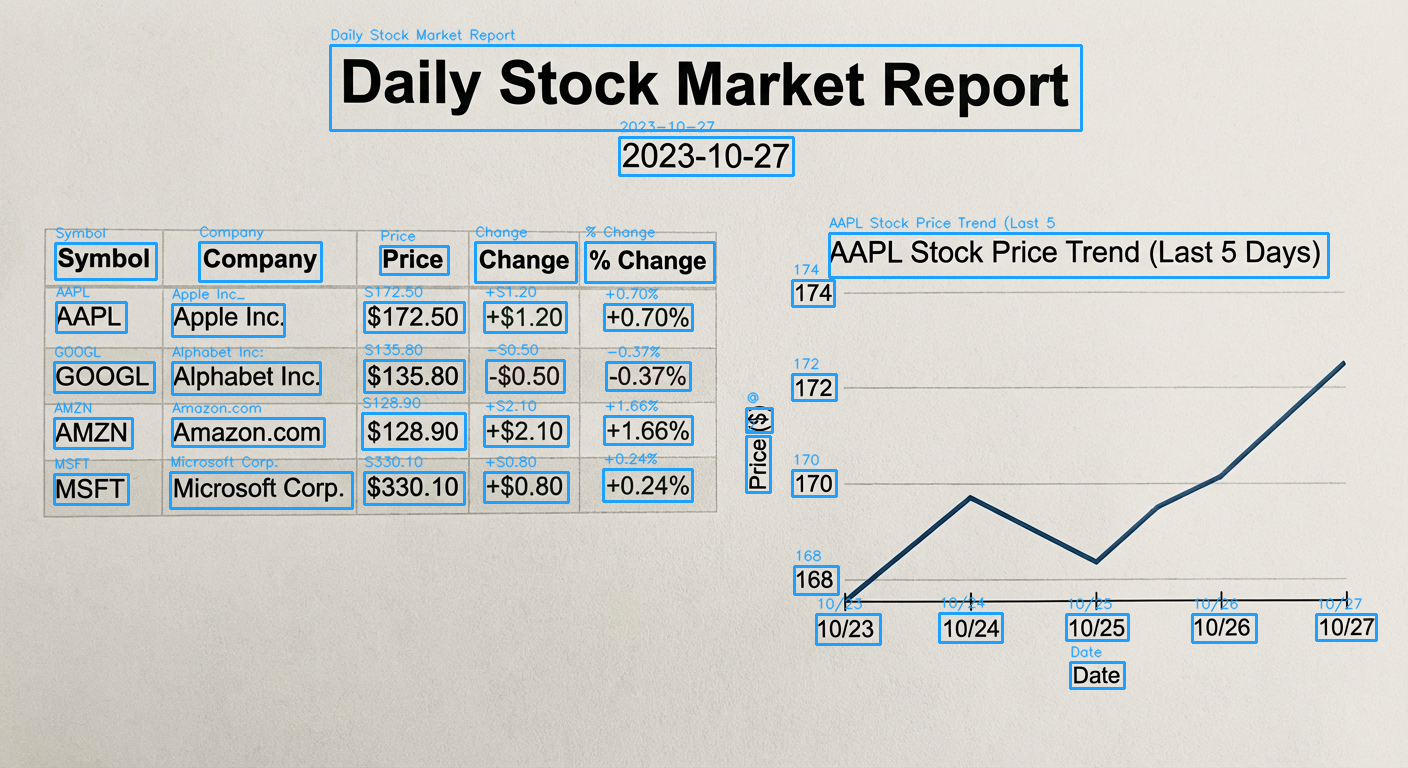

In [12]:
import cv2
import numpy as np
from IPython.display import display
from PIL import Image as PILImage

def draw_ocr_regions(image_path: str, ocr_result) -> np.ndarray:
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for region in ocr_result.regions:
        if region.bbox is None:
            continue
        x1, y1, x2, y2 = map(int, region.bbox)
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (30, 160, 255), 2)
        label = region.text[:30]
        cv2.putText(img_rgb, label, (x1, max(y1 - 6, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (30, 160, 255), 1, cv2.LINE_AA)
    return img_rgb

annotated = draw_ocr_regions(STOCKS_IMAGE, ocr_result)
display(PILImage.fromarray(annotated))

## 8. Export Results

Save OCR output in multiple formats: plain text, CSV, JSON, and annotated image overlay.

In [13]:
out_dir = Path("runs/ocr")
out_dir.mkdir(parents=True, exist_ok=True)

ocr_result.save(str(out_dir / "output.txt"))                               # plain text
ocr_result.save(str(out_dir / "output.csv"))                               # CSV rows
ocr_result.save(str(out_dir / "output.json"))                              # structured JSON
ocr_result.save(str(out_dir / "overlay.png"), source_image=STOCKS_IMAGE)   # annotated image

print(f"Saved to {out_dir}/")
print(f"  output.txt  — {len(ocr_result.full_text)} chars")
print(f"  output.csv  — {len(ocr_result.regions)} rows")
print(f"  output.json")
print(f"  overlay.png — bbox annotations")

[INFO] Exported 40 OCR regions to runs\ocr\output.csv
[INFO] Exported JSON to runs\ocr\output.json
[INFO] Exported OCR overlay to runs\ocr\overlay.png
Saved to runs\ocr/
  output.txt  — 326 chars
  output.csv  — 40 rows
  output.json
  overlay.png — bbox annotations


## 9. One-Shot via `mata.run()`

Skip `mata.load()` when you only need a single result.

In [14]:
result_oneshot = mata.run("ocr", RECEIPT_IMAGE, model="easyocr")
print(result_oneshot.full_text[:300])
result_oneshot

[INFO] Loading ocr model from external_engine: easyocr
[INFO] Initializing EasyOCR reader for languages: ['en'], gpu=True
[INFO] EasyOCR reader initialized successfully
The
Corner
Market
2023-10-27
1
X
Milk
$3.50
2
X
Bread
$5.00
1
X
Eggs
$4.25
Subtotal:
$12.75
Tax:
s0.90
Total:
S13.65


Text,Score,BBox,Label
The,1.000,"(467, 77, 557, 121)",—
Corner,1.000,"(577, 75, 756, 125)",—
Market,0.608,"(776, 74, 954, 124)",—
2023-10-27,0.692,"(586, 138, 832, 186)",—
1,1.000,"(352, 266, 380, 300)",—
X,0.997,"(393, 267, 429, 303)",—
Milk,1.000,"(443, 259, 551, 303)",—
$3.50,0.677,"(612, 258, 744, 308)",—
2,1.000,"(348, 320, 380, 356)",—
X,0.998,"(391, 323, 427, 359)",—


## Notes

| API | Description |
|-----|-------------|
| `mata.load("ocr", "easyocr", languages=["en"])` | Load adapter once |
| `mata.run("ocr", img, model="easyocr")` | One-shot run |
| `result.full_text` | Concatenated text from all regions |
| `result.regions` | List of `TextRegion` objects |
| `region.text` | Recognized text string |
| `region.score` | Confidence (0–1) |
| `region.bbox` | `(x1, y1, x2, y2)` pixel coords, or `None` |
| `result.filter_by_score(threshold)` | Returns new `OCRResult` with high-confidence regions |
| `result.save("out.txt")` | Plain text output |
| `result.save("out.csv")` | CSV (text, score, bbox columns) |
| `result.save("out.json")` | Structured JSON |
| `result.save("overlay.png", source_image=img)` | Annotated image |

`OCRResult` auto-renders as a rich HTML table when evaluated in a notebook cell.